# Hugo Onghai (hpo8)
## ECE 5242, Project 1

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
from skimage import color
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

In [3]:
# get necessary image dirs
cwd = Path.cwd()

training_path = (cwd / 'ECE5242Proj1-train').resolve()
cone_path = (cwd / 'cone_masks').resolve()
bkgd_path = (cwd / 'bkgd_masks').resolve()

In [4]:
# inspired by: Prof. Volodymyr Kuleshov's Applied Machine Learning at Cornell Tech textbook
# adapted to preserve pixel-image positioning with a dim=3 matrix instead of feature matrix
def gmm_predictions(x, mus, Sigmas, phis):
    """This returns class assignments and p(y|x) under the GDA model.
    
    We compute \arg\max_y p(y|x) as \arg\max_y p(x|y)p(y)

    I tried to allow for two formats to be accepted:
    - image-esque formatting (H by W by 6) where H and W are the height and width of the image in pixels respectively
    - list-esque formatting (H*W by 6) where all of the pixels are listed in line, like a feature/dataset matrix
    """
    H = None
    if x.ndim == 3: # image-esque
        H, W, d = x.shape
        x = x.reshape(-1, d)

    # adjust shapes
    K = len(phis)
    n, d = np.shape(x)
    x = x.reshape((1, n, d, 1))
    mus = mus.reshape((K, 1, d, 1))
    Sigmas = Sigmas.reshape((K, 1, d, d))    
    
    # compute probabilities
    py = np.tile(phis.reshape((K,1)), (1,n)).reshape([K,n,1,1])

    # calculate p(x|y)
    coef = (1 / np.sqrt(np.abs((2*np.pi)**d*np.linalg.det(Sigmas))).reshape((K,1,1,1)))
    gaussian = np.exp(-0.5 * (x-mus).transpose([0,1,3,2]) @ np.linalg.inv(Sigmas) @ (x-mus))
    pxy = coef * gaussian

    pyx = pxy * py / ((pxy * py).sum(axis=0) + 1e-8) # normalization
    y_pred = pyx.argmax(axis=0)

    if H is not None: # means that x.ndim was originally 3
        y_pred = y_pred.reshape(H, W)
        pyx = pyx.reshape([H, W, K])
    else:
        y_pred = y_pred.flatten()
        pyx = pyx.reshape([K,n])

    return y_pred, pyx

In [5]:
def predict_from_RGB(RGB, mus, Sigmas, phis):
    hsv = color.rgb2hsv(RGB)
    ycbcr = color.rgb2ycbcr(RGB)

    if RGB.ndim == 1:
        n = 1
        x = np.concatenate((hsv, ycbcr))
        x = x / feature_max.reshape(1, 6)
        print(x.shape)
        prediction = gmm_predictions(x, mus, Sigmas, phis)
        return prediction[0]
    else:
        xdim, ydim, d = RGB.shape
        x = np.concatenate((hsv, ycbcr), axis=2)
        x = x / feature_max.reshape(1, 1, 6)
        prediction, likelihoods = gmm_predictions(x, mus, Sigmas, phis)
        return prediction.reshape([xdim,ydim])

In [6]:
CONE_HEIGHT_M = 0.4318 # meters
CONE_DIAM_M = 0.1905 # meters

FOCAL_LENGTH = 710

def estimate_distance_from_bbox(height, width, tol=0.35):
    # height and width should be in units of pixels
    # first determine the ratio of the bbox and decide which dimension to use
    aspect_ratio = height / width
    true_aspect_ratio = CONE_HEIGHT_M / CONE_DIAM_M

    ratio_error = abs(aspect_ratio - true_aspect_ratio) / true_aspect_ratio
    
    if ratio_error < tol: # then likely the full cone is visible
        Z_from_width = CONE_DIAM_M * FOCAL_LENGTH / width
        Z_from_height = CONE_HEIGHT_M * FOCAL_LENGTH / height

        Z_estimate = (Z_from_width + Z_from_height) / 2.0
    elif aspect_ratio > true_aspect_ratio: # then likely the base of the cone is partially obscured, use only height
        Z_estimate = CONE_DIAM_M * FOCAL_LENGTH / width
    else: # then the top or base of the cone is obscured, only use width
        Z_estimate = CONE_HEIGHT_M * FOCAL_LENGTH / height

    return Z_estimate * 100 # convert to cm

In [7]:
# NEW ADDITION TO LOAD SAVED MODEL
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

params = np.load('gda_model.npz')
mus = params['mus']
Sigmas = params['Sigmas']
phis = params['phis']
feature_max = params['feature_max']

# get necessary image dirs
cwd = Path.cwd()

training_path = (cwd / 'ECE5242Proj1-train').resolve()
cone_path = (cwd / 'cone_masks').resolve()
bkgd_path = (cwd / 'bkgd_masks').resolve()

ImageName: test_1.png, Down: 208, Right: 342, Distance: 346.80769230769226 cm


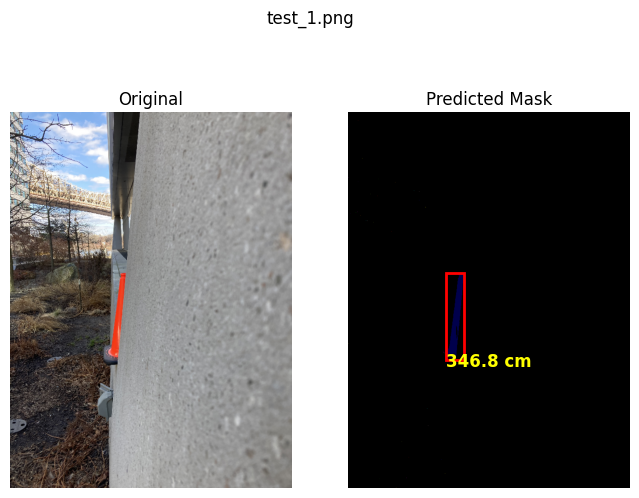

ImageName: test_2.png, Down: 412, Right: 305, Distance: 118.75811965811967 cm


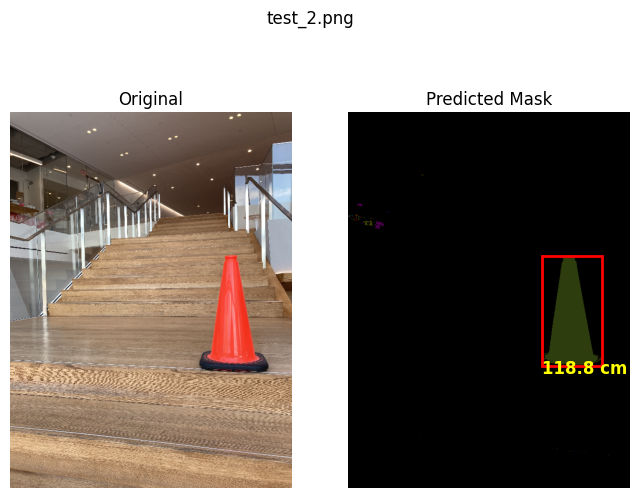

ImageName: test_3.png, Down: 288, Right: 336, Distance: 243.43716707021792 cm


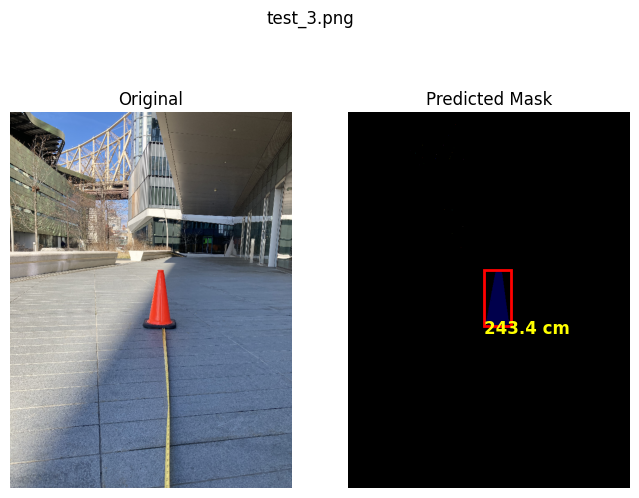

ImageName: test_4.png, Down: 291, Right: 374, Distance: 696.576432748538 cm
ImageName: test_4.png, Down: 254, Right: 153, Distance: 1057.1655172413796 cm


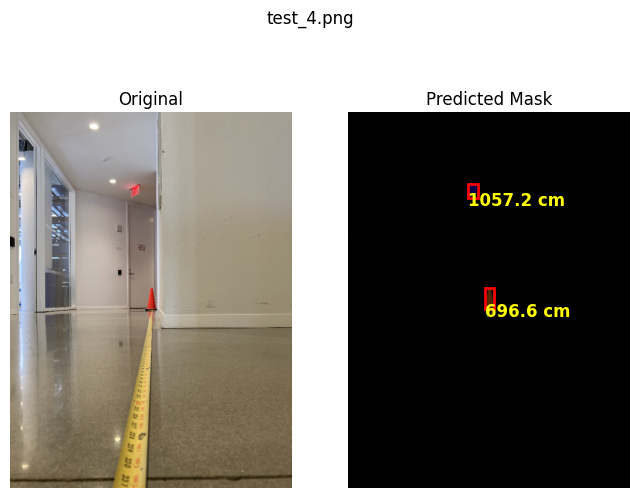

ImageName: test_5.png, Down: 278, Right: 303, Distance: 101.16536468614292 cm
ImageName: test_5.png, Down: 237, Right: 324, Distance: 239.59207502768552 cm


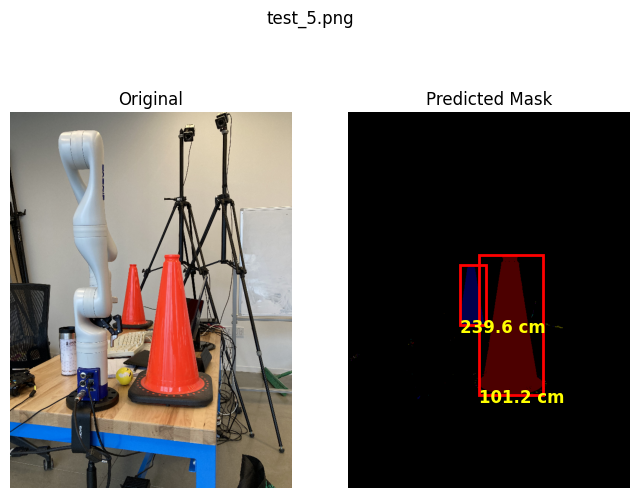

ImageName: train_1_dist915.png, Down: 306, Right: 400, Distance: 929.8781250000001 cm
ImageName: train_1_dist915.png, Down: 165, Right: 400, Distance: 1074.5258333333334 cm


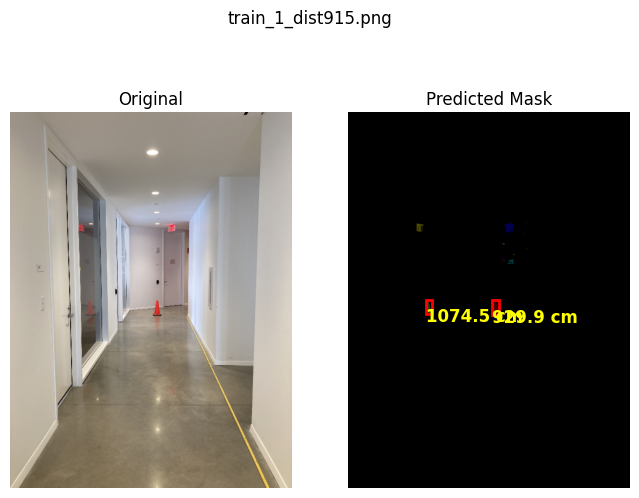

ImageName: train_3_dist460.png, Down: 57, Right: 459, Distance: 505.8181650246306 cm


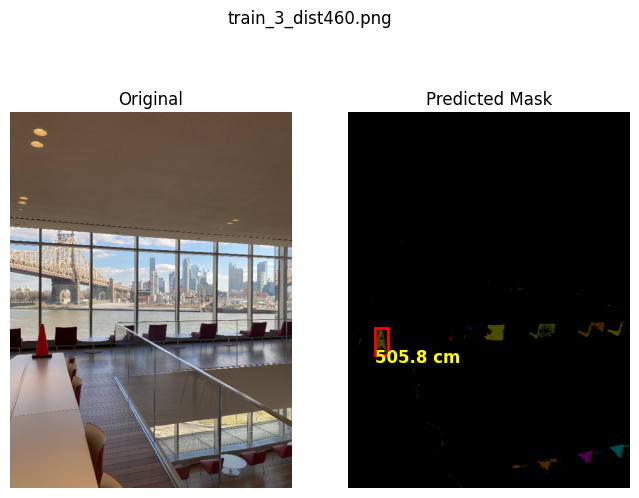

ImageName: train_6_dist305.png, Down: 508, Right: 382, Distance: 279.37034373248645 cm


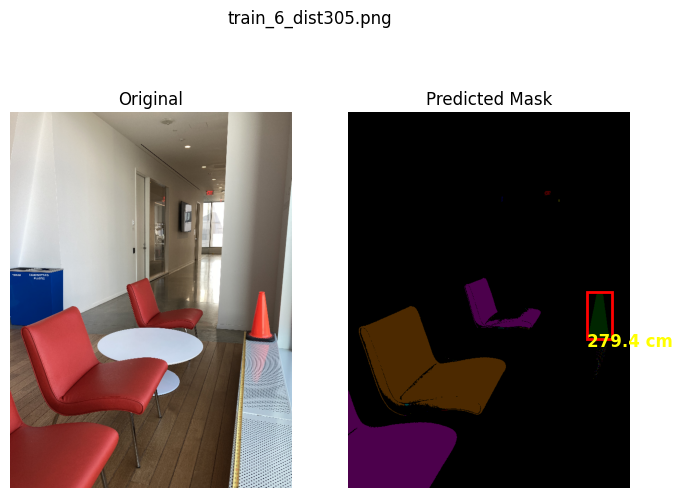

ImageName: train_2_dist305.png, Down: 142, Right: 379, Distance: 362.9163043478261 cm
ImageName: train_2_dist305.png, Down: 15, Right: 469, Distance: 578.4490566037737 cm
ImageName: train_2_dist305.png, Down: 31, Right: 404, Distance: 1135.4740740740742 cm


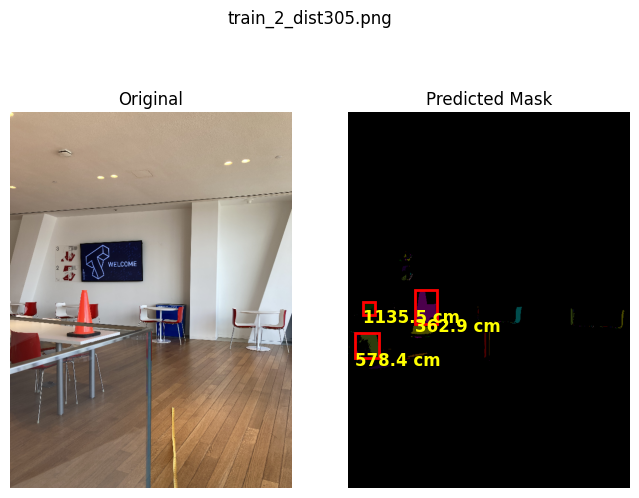

ImageName: train_4_dist450.png, Down: 121, Right: 114, Distance: 155.2840505226481 cm
ImageName: train_4_dist450.png, Down: 542, Right: 221, Distance: 285.0485884804851 cm


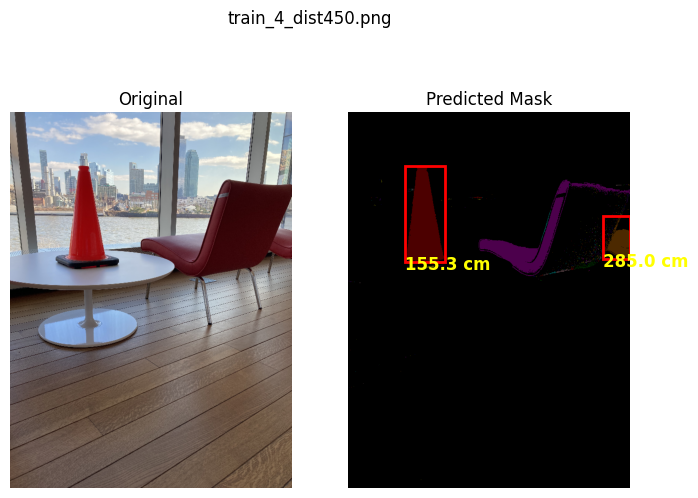

ImageName: train_5_dist760.png, Down: 124, Right: 359, Distance: 758.9308333333333 cm
ImageName: train_5_dist760.png, Down: 126, Right: 402, Distance: 854.2421052631578 cm


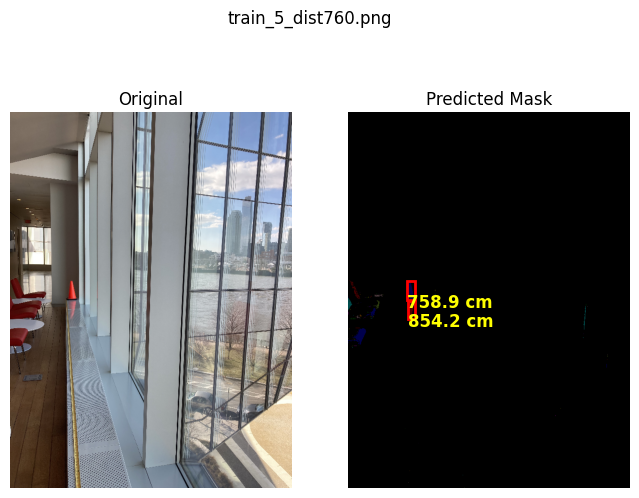

ImageName: train_7_dist305.png, Down: 480, Right: 596, Distance: 138.3289772727273 cm
ImageName: train_7_dist305.png, Down: 318, Right: 735, Distance: 471.6584615384616 cm
ImageName: train_7_dist305.png, Down: 275, Right: 637, Distance: 828.5891891891893 cm


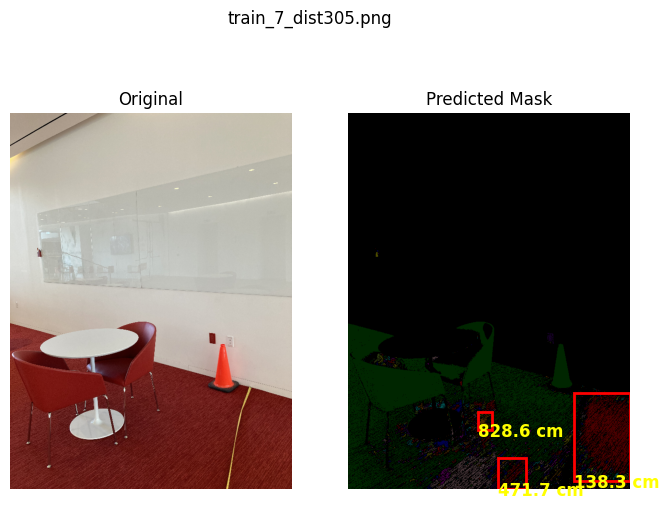

ImageName: train_10_dist610.png, Down: 479, Right: 370, Distance: 620.2324211502784 cm


In [ ]:
import cv2, os
# folder = "ECE5242Proj1-train"
folder = "Proj1TestImages"

testing_files = (cwd / folder).resolve().glob('*.png')

for filename in testing_files:
    path = os.path.join(folder, filename)
    imageName = os.path.basename(filename)
    
    # read one test image
    img = cv2.imread(path)

    if img is None:
        print("Skipping: ", path)
        continue
    
    img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 2, figsize=(8,6))
    plt.suptitle(imageName)
    for axis in ax.ravel():
        axis.set_axis_off()

    ax[0].imshow(img2)
    ax[0].set_title("Original")

    pred_mask = predict_from_RGB(img2, mus, Sigmas, phis)
    ax[1].imshow(pred_mask)
    ax[1].set_title("Predicted Mask")

    # following project guidelines and label image regions example with coins on scikit-image
    # https://scikit-image.org/docs/dev/auto_examples/segmentation/plot_label.html
    from skimage.measure import label, regionprops 
    from skimage.color import label2rgb
    import matplotlib.patches as mpatches
    
    label_pm = label(pred_mask, connectivity=pred_mask.ndim)
    label_pm_overlay = label2rgb(label_pm, image=pred_mask, bg_label=0)
    
    ax[1].imshow(label_pm_overlay)

    num_cones_detected = 0
    
    props = regionprops(label_pm)
    for region in sorted(
        props,
        key = lambda r: r.area,
        reverse = True
    ): # sorting regions by decreasing size (source: https://stackoverflow.com/questions/63974593/how-to-order-the-regions-in-regionprops-by-area)
        # take regions with large enough areas
        minr, minc, maxr, maxc = region.bbox
        height = maxr-minr
        width = maxc-minc

        if num_cones_detected > 2:
            break
        
        if region.area >= 200 and height > width: # assuming now that the cone should be shown taller than it is wide, but could fail is cone is sideways or more than halfway obscured in height
            num_cones_detected += 1
            
            rect = mpatches.Rectangle(
                (minc, minr),
                width,
                height,
                fill = False,
                edgecolor = 'red',
                linewidth = 2
            )
            ax[1].add_patch(rect)

            Z_estimate = estimate_distance_from_bbox(height, width)
            print(f"ImageName: {imageName}, Down: {minc}, Right: {minr}, Distance: {Z_estimate} cm")

            plt.text(
                x = minc,
                y = maxr + 15,
                s = f"{Z_estimate:.1f} cm",
                color = "yellow",
                fontsize = 12,
                weight = "bold"
            )

    out_path = os.path.join("./GDA_results", imageName)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()